In [86]:
#import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score


In [87]:
# Load the synthetic dataset
df = pd.read_csv('synthetic_diabetes_data_v2.csv')

# Quick check
df.head()


,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness,Condition
0,7.300000,2.500000,4,14,36,0,1,1,0,1,1,0
1,11.500000,3.900000,4,11,0,0,0,0,0,0,0,1
2,17.201293,20.486419,0,0,56,1,1,1,0,1,0,3
3,10.000000,5.400000,2,12,19,0,0,0,0,0,0,1
4,4.300000,4.500000,1,18,16,0,0,0,0,0,0,1


In [88]:

# Map numeric labels to condition names
condition_map = {0: "Hypoglycemia", 1: "Normal", 2: "Hyperglycemia", 3: "DKA"}
y = df['Condition']

# Unique numeric labels
unique_labels = y.unique()
print("Unique numeric labels:", unique_labels)

# Unique condition names
unique_conditions = [condition_map[label] for label in unique_labels]
print("Unique conditions:", unique_conditions)


Unique numeric labels: [0 1 3 2]
Unique conditions: ['Hypoglycemia', 'Normal', 'DKA', 'Hyperglycemia']


In [89]:
print("Class distribution in full dataset:")
print(df['Condition'].value_counts().sort_index())
print("\nPercentage:")
print(df['Condition'].value_counts(normalize=True).sort_index() * 100)

Class distribution in full dataset:
Condition
0    6668
1    1730
2     700
3     902
Name: count, dtype: int64

Percentage:
Condition
0    66.68
1    17.30
2     7.00
3     9.02
Name: proportion, dtype: float64


In [90]:
# Features (all columns except 'Condition')
X = df.drop('Condition', axis=1)

# Labels (Condition column)
y = df['Condition']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [91]:
# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [92]:
# Read the CSV using tab separator
real_df = pd.read_csv('real_data.csv', sep='\t')

# Check column names
print(real_df.columns)

# Check column names

print("Columns in file:\n", real_df.columns.tolist())


Index(['ID', 'Time', 'Record Type', 'Historic Glucose (mmol/L)',
       'Scan Glucose (mmol/L)', 'Non-numeric Rapid-Acting Insulin',
       'Rapid-Acting Insulin (units)', 'Non-numeric Food',
       'Carbohydrates (grams)', 'Non-numeric Long-Acting Insulin',
       'Long-Acting Insulin (units)', 'Notes', 'Strip Glucose (mmol/L)',
       'Ketone (mmol/L)', 'Meal Insulin (units)', 'Correction Insulin (units)',
       'User Change Insulin (units)', 'Previous Time', 'Updated Time'],
      dtype='object')
Columns in file:
 ['ID', 'Time', 'Record Type', 'Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 'Non-numeric Rapid-Acting Insulin', 'Rapid-Acting Insulin (units)', 'Non-numeric Food', 'Carbohydrates (grams)', 'Non-numeric Long-Acting Insulin', 'Long-Acting Insulin (units)', 'Notes', 'Strip Glucose (mmol/L)', 'Ketone (mmol/L)', 'Meal Insulin (units)', 'Correction Insulin (units)', 'User Change Insulin (units)', 'Previous Time', 'Updated Time']


In [93]:
# Select only columns relevant to the model
needed_cols = [
    'Historic Glucose (mmol/L)',
    'Scan Glucose (mmol/L)',
    'Rapid-Acting Insulin (units)',
    'Long-Acting Insulin (units)',
    'Carbohydrates (grams)'
]

# Keep only required columns
real_df = real_df[needed_cols]

# Check for missing values
print("Missing values before filling:\n", real_df.isnull().sum())


Missing values before filling:
 Historic Glucose (mmol/L)        1676
Scan Glucose (mmol/L)           11632
Rapid-Acting Insulin (units)    12788
Long-Acting Insulin (units)     12920
Carbohydrates (grams)           12781
dtype: int64


In [94]:
#  — Clean and replace zeros with median value
import numpy as np

# Replace zeros with NaN for easy processing
real_df['Historic Glucose (mmol/L)'] = real_df['Historic Glucose (mmol/L)'].replace(0, np.nan)

# Compute median of valid values
median_glucose = real_df['Historic Glucose (mmol/L)'].median()

# Fill missing values with median
real_df['Historic Glucose (mmol/L)'] = real_df['Historic Glucose (mmol/L)'].fillna(median_glucose)

print(" Historic Glucose cleaned — zeros replaced with median value:", median_glucose)


 Historic Glucose cleaned — zeros replaced with median value: 7.7


In [95]:
#  — Fix Scan Glucose zeros using Historic Glucose or median
median_scan = real_df['Scan Glucose (mmol/L)'].median()

real_df['Scan Glucose (mmol/L)'] = real_df.apply(
    lambda row: row['Historic Glucose (mmol/L)']
    if row['Scan Glucose (mmol/L)'] == 0 else row['Scan Glucose (mmol/L)'],
    axis=1
)

# Fill any remaining zeros with the median value
real_df['Scan Glucose (mmol/L)'] = real_df['Scan Glucose (mmol/L)'].replace(0, median_scan)

# Confirm fix
print(" Scan Glucose cleaned — summary:")
print(real_df[['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)']].describe())


 Scan Glucose cleaned — summary:
       Historic Glucose (mmol/L)  Scan Glucose (mmol/L)
count               12949.000000            1317.000000
mean                    8.085667               8.795444
std                     2.866533               3.019155
min                     2.200000               2.900000
25%                     6.200000               6.400000
50%                     7.700000               8.400000
75%                     9.600000              10.900000
max                    24.200000              19.100000


In [96]:
# Create symptom columns initialized to 0
symptom_cols = ['Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness']
for col in symptom_cols:
    real_df[col] = 0

# Apply logic based on glucose levels (FIXED TO MATCH TRAINING DATA)
for i, row in real_df.iterrows():
    glucose = row['Scan Glucose (mmol/L)']
    
    # Hypoglycemia (<3.9)
    if glucose < 3.9:
        real_df.at[i, 'Shakiness'] = 1
        real_df.at[i, 'Weakness'] = 1
        real_df.at[i, 'Fatigue'] = 1
    
    # NORMAL RANGE (3.9-7.0)
    elif 3.9 <= glucose < 7.0:
        # Borderline low (3.9-5.0) might have mild shakiness
        if glucose < 5.0:
            real_df.at[i, 'Shakiness'] = 1
    
    # Hyperglycemia (7.0-13.9) 
    elif 7.0 <= glucose < 14.0: 
        real_df.at[i, 'Thirst'] = 1
        real_df.at[i, 'Fatigue'] = 1
        # Add Nausea for higher hyperglycemia
        if glucose >= 10:
            real_df.at[i, 'Nausea'] = 1
    
    # DKA (≥14.0)
    elif glucose >= 14.0: 
        real_df.at[i, 'Thirst'] = 1
        real_df.at[i, 'Nausea'] = 1
        real_df.at[i, 'Vomiting'] = 1
        real_df.at[i, 'Fatigue'] = 1
        real_df.at[i, 'Weakness'] = 1

print(" Symptoms assigned successfully!")
print("\nSample data:")
print(real_df[['Scan Glucose (mmol/L)', 'Shakiness', 'Thirst', 'Fatigue']].head())

 Symptoms assigned successfully!

Sample data:
   Scan Glucose (mmol/L)  Shakiness  Thirst  Fatigue
0                    8.8          0       1        1
1                   10.4          0       1        1
2                    NaN          0       0        0
3                   14.2          0       1        1
4                   14.5          0       1        1


In [97]:
# Show the updated dataframe with all important columns
print("Final cleaned and symptom-augmented dataset:\n")
real_df[
    [
        'Historic Glucose (mmol/L)',
        'Scan Glucose (mmol/L)',
        'Rapid-Acting Insulin (units)',
        'Long-Acting Insulin (units)',
        'Carbohydrates (grams)',
        'Thirst',
        'Nausea',
        'Weakness',
        'Vomiting',
        'Fatigue',
        'Shakiness'
    ]
].head(20) 


Final cleaned and symptom-augmented dataset:



,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness
0,7.7,8.8,NaN,NaN,NaN,1,0,0,0,1,0
1,7.7,10.4,NaN,NaN,NaN,1,1,0,0,1,0
2,7.7,NaN,2.0,NaN,NaN,0,0,0,0,0,0
3,7.7,14.2,NaN,NaN,NaN,1,1,1,1,1,0
4,7.7,14.5,NaN,NaN,NaN,1,1,1,1,1,0
5,7.7,6.2,NaN,NaN,NaN,0,0,0,0,0,0
6,7.7,6.2,NaN,NaN,NaN,0,0,0,0,0,0
7,7.7,NaN,NaN,12.0,NaN,0,0,0,0,0,0
8,7.7,6.8,NaN,NaN,NaN,0,0,0,0,0,0
9,7.7,6.2,NaN,NaN,NaN,0,0,0,0,0,0


In [98]:
#  — Arrange columns in the same order as training
feature_cols = [
    'Historic Glucose (mmol/L)',
    'Scan Glucose (mmol/L)',
    'Rapid-Acting Insulin (units)',
    'Long-Acting Insulin (units)',
    'Carbohydrates (grams)'
] + symptom_cols

real_df = real_df[feature_cols]

print(" Final dataset ready for prediction:")
display(real_df.head())


 Final dataset ready for prediction:


,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness
0,7.7,8.8,NaN,NaN,NaN,1,0,0,0,1,0
1,7.7,10.4,NaN,NaN,NaN,1,1,0,0,1,0
2,7.7,NaN,2.0,NaN,NaN,0,0,0,0,0,0
3,7.7,14.2,NaN,NaN,NaN,1,1,1,1,1,0
4,7.7,14.5,NaN,NaN,NaN,1,1,1,1,1,0


In [99]:
# Fill insulin and carb NaNs with 0 (means no dose or no meal)
real_df['Rapid-Acting Insulin (units)'] = real_df['Rapid-Acting Insulin (units)'].fillna(0)
real_df['Long-Acting Insulin (units)'] = real_df['Long-Acting Insulin (units)'].fillna(0)
real_df['Carbohydrates (grams)'] = real_df['Carbohydrates (grams)'].fillna(0)

# Use ffill() instead of fillna(method='ffill') - NEW SYNTAX
real_df['Scan Glucose (mmol/L)'] = real_df['Scan Glucose (mmol/L)'].ffill()
real_df['Historic Glucose (mmol/L)'] = real_df['Historic Glucose (mmol/L)'].ffill()

# Fill any remaining NaNs with median
real_df['Scan Glucose (mmol/L)'] = real_df['Scan Glucose (mmol/L)'].fillna(
    real_df['Scan Glucose (mmol/L)'].median()
)
real_df['Historic Glucose (mmol/L)'] = real_df['Historic Glucose (mmol/L)'].fillna(
    real_df['Historic Glucose (mmol/L)'].median()
)

print("Missing values after cleaning:\n", real_df.isnull().sum())
real_df.head()

Missing values after cleaning:
 Historic Glucose (mmol/L)       0
Scan Glucose (mmol/L)           0
Rapid-Acting Insulin (units)    0
Long-Acting Insulin (units)     0
Carbohydrates (grams)           0
Thirst                          0
Nausea                          0
Weakness                        0
Vomiting                        0
Fatigue                         0
Shakiness                       0
dtype: int64


,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness
0,7.7,8.8,0.0,0.0,0.0,1,0,0,0,1,0
1,7.7,10.4,0.0,0.0,0.0,1,1,0,0,1,0
2,7.7,10.4,2.0,0.0,0.0,0,0,0,0,0,0
3,7.7,14.2,0.0,0.0,0.0,1,1,1,1,1,0
4,7.7,14.5,0.0,0.0,0.0,1,1,1,1,1,0


In [100]:
def assign_condition_v2_fixed(glucose, thirst, nausea, vomiting, weakness, fatigue, shakiness):
    """
    FIXED VERSION for real data - uses FIXED thresholds for consistency.
    
    Key differences from training:
    - NO random noise (reproducible results)
    - Same symptom-based borderline logic
    - Clinically consistent classification
    
    Training data has noise to prevent overfitting.
    Real data uses fixed thresholds for reproducible diagnosis.
    """
    
    # Fixed thresholds (NO noise for real data)
    hypo_threshold = 3.9
    normal_upper = 7.0
    hyper_upper = 14.0
    
    # Base classification
    if glucose < hypo_threshold:
        base_condition = 0  # Hypoglycemia
    elif glucose < normal_upper:
        base_condition = 1  # Normal
    elif glucose < hyper_upper:
        base_condition = 2  # Hyperglycemia
    else:
        base_condition = 3  # DKA
    
    # =========================================
    # SYMPTOM-BASED ADJUSTMENTS (SAME AS TRAINING)
    # =========================================
    
    # Borderline Hypo/Normal (3.7-4.2)
    if 3.7 <= glucose <= 4.2:
        if weakness == 1 and (shakiness == 1 or fatigue == 1):
            return 0  # Hypoglycemia
        else:
            return 1  # Normal
    
    # Borderline Normal/Hyper (6.5-7.5)
    if 6.5 <= glucose <= 7.5:
        if thirst == 1 and fatigue == 1:
            return 2  # Hyperglycemia
        else:
            return 1  # Normal
    
    # Borderline Hyper/DKA (13.0-14.5)
    if 13.0 <= glucose <= 14.5:
        severe_symptoms = thirst + nausea + weakness + vomiting + fatigue
        
        if severe_symptoms >= 4:
            return 3  # DKA
        elif severe_symptoms >= 2 and glucose >= 13.5:
            return 3  # DKA
        else:
            return 2  # Hyperglycemia
    
    # High glucose with ALL severe symptoms = DKA (even if <14)
    if 12.0 <= glucose < 14.0:
        if (thirst == 1 and nausea == 1 and 
            vomiting == 1 and weakness == 1):
            return 3  # Clinical DKA
    
    return base_condition


# Apply to real data
print("🩺 Assigning conditions to real data (fixed thresholds)...")
real_df['Condition'] = real_df.apply(
    lambda row: assign_condition_v2_fixed(
        row['Scan Glucose (mmol/L)'],
        row['Thirst'],
        row['Nausea'],
        row['Vomiting'],
        row['Weakness'],
        row['Fatigue'],
        row['Shakiness']
    ),
    axis=1
)

print("✅ Conditions assigned!")
print("\nCondition distribution in real data:")
print(real_df['Condition'].value_counts().sort_index())

🩺 Assigning conditions to real data (fixed thresholds)...
✅ Conditions assigned!

Condition distribution in real data:
Condition
0       26
1      558
2    12248
3      117
Name: count, dtype: int64


In [101]:
from collections import Counter

# Check current distribution
print("Original class distribution:")
print(real_df['Condition'].value_counts().sort_index())

# find minimum class size
class_counts = Counter(real_df['Condition'])
min_samples = min(class_counts.values())

print(f"\nBalancing to minimum class size: {min_samples} samples per class")

# Balance the dataset by sampling
balanced_dfs = []
for condition_class in range(4):
    class_df = real_df[real_df['Condition'] == condition_class]
    
    if len(class_df) >= min_samples:
        sampled = class_df.sample(min_samples, random_state=42)
    else:
        print(f" Warning: Class {condition_class} has only {len(class_df)} samples")
        sampled = class_df  # Use all available
    
    balanced_dfs.append(sampled)

balanced_real_df = pd.concat(balanced_dfs, ignore_index=True)
print(f"\nBalanced dataset size: {len(balanced_real_df)}")
print("\nBalanced class distribution:")
print(balanced_real_df['Condition'].value_counts().sort_index())

Original class distribution:
Condition
0       26
1      558
2    12248
3      117
Name: count, dtype: int64

Balancing to minimum class size: 26 samples per class

Balanced dataset size: 104

Balanced class distribution:
Condition
0    26
1    26
2    26
3    26
Name: count, dtype: int64


In [102]:
# Ensure columns match training data exactly
X_real = balanced_real_df[X_train.columns]  # Use X_train columns order
y_true = balanced_real_df['Condition']

# Verify
print("Training features:", X_train.columns.tolist())
print("Real data features:", X_real.columns.tolist())
print("Features match:", list(X_train.columns) == list(X_real.columns))
print("\nMissing values:", X_real.isnull().sum().sum())

Training features: ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)', 'Carbohydrates (grams)', 'Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness']
Real data features: ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)', 'Carbohydrates (grams)', 'Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness']
Features match: True

Missing values: 0


 Model Accuracy on Balanced Real Data: 0.9038461538461539

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        26
           2       0.74      0.96      0.83        26
           3       0.94      0.65      0.77        26

    accuracy                           0.90       104
   macro avg       0.92      0.90      0.90       104
weighted avg       0.92      0.90      0.90       104



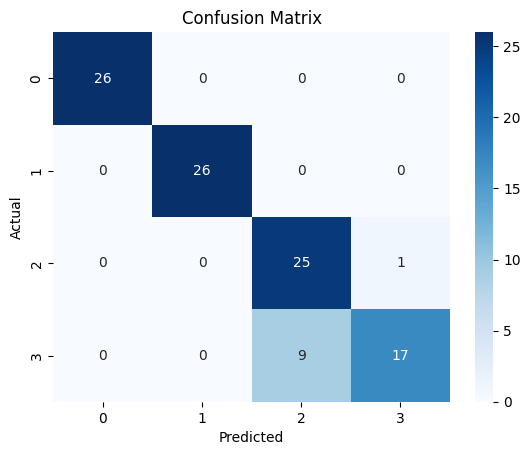

In [103]:


y_pred_real = rf_model.predict(X_real)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
accuracy = accuracy_score(y_true, y_pred_real)
print(" Model Accuracy on Balanced Real Data:", accuracy)

# Classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred_real))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_real)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [104]:
print("Synthetic data glucose range:", df['Scan Glucose (mmol/L)'].describe())
print("Real data glucose range:", real_df['Scan Glucose (mmol/L)'].describe())


Synthetic data glucose range: count    10000.000000
mean         4.974017
std          4.716575
min          2.500000
25%          2.500000
50%          2.500000
75%          5.500000
max         24.908464
Name: Scan Glucose (mmol/L), dtype: float64
Real data glucose range: count    12949.000000
mean         8.270500
std          1.111002
min          2.900000
25%          8.200000
50%          8.200000
75%          8.200000
max         19.100000
Name: Scan Glucose (mmol/L), dtype: float64


FEATURE IMPORTANCE ANALYSIS

Feature Importance Ranking:
                     Feature  Importance
       Scan Glucose (mmol/L)    0.388793
                   Shakiness    0.205069
                     Fatigue    0.083383
                    Weakness    0.065415
                      Thirst    0.063524
Rapid-Acting Insulin (units)    0.041244
                    Vomiting    0.039880
                      Nausea    0.039028
       Carbohydrates (grams)    0.030800
   Historic Glucose (mmol/L)    0.026179
 Long-Acting Insulin (units)    0.016684


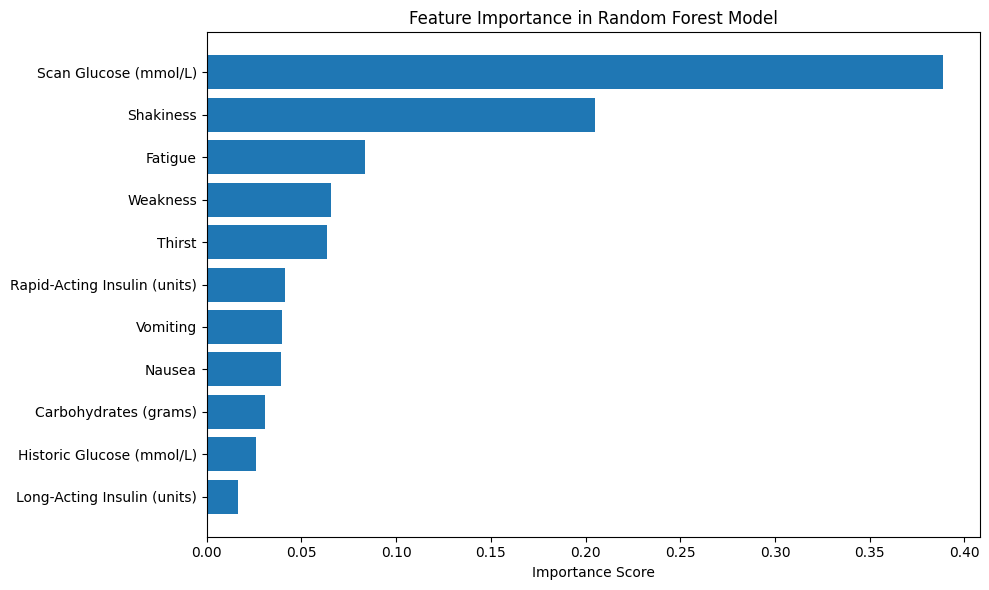

In [105]:

#  FEATURE IMPORTANCE ANALYSIS

print("FEATURE IMPORTANCE ANALYSIS")

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Ranking:")
print(feature_importance.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [106]:

#  BASELINE MODEL PERFORMANCE


print(" BASELINE MODEL PERFORMANCE")


# Test set performance: how well your model learned from synthetic patterns.
y_pred_test = rf_model.predict(X_test)
baseline_test_acc = accuracy_score(y_test, y_pred_test)
print(f"\nTest Set Accuracy (All Features): {baseline_test_acc:.4f}")

# Real data performance: how well it transfers that learning to actual patient data.
y_pred_real = rf_model.predict(X_real)
baseline_real_acc = accuracy_score(y_true, y_pred_real)
print(f"Real Data Accuracy (All Features): {baseline_real_acc:.4f}")

 BASELINE MODEL PERFORMANCE

Test Set Accuracy (All Features): 0.9920
Real Data Accuracy (All Features): 0.9038


 ABLATION STUDY - REMOVING ONE FEATURE AT A TIME

 Testing WITHOUT: Historic Glucose (mmol/L)
   Test Accuracy: 0.9930 (Impact: -0.0010)
   Real Accuracy: 0.9327 (Impact: -0.0385)

 Testing WITHOUT: Scan Glucose (mmol/L)
   Test Accuracy: 0.9470 (Impact: +0.0450)
   Real Accuracy: 0.5481 (Impact: +0.3462)

 Testing WITHOUT: Rapid-Acting Insulin (units)
   Test Accuracy: 0.9935 (Impact: -0.0015)
   Real Accuracy: 0.9135 (Impact: -0.0192)

 Testing WITHOUT: Long-Acting Insulin (units)
   Test Accuracy: 0.9920 (Impact: +0.0000)
   Real Accuracy: 0.9038 (Impact: -0.0096)

 Testing WITHOUT: Carbohydrates (grams)
   Test Accuracy: 0.9935 (Impact: -0.0015)
   Real Accuracy: 0.9135 (Impact: -0.0192)

 Testing WITHOUT: Thirst
   Test Accuracy: 0.9920 (Impact: +0.0000)
   Real Accuracy: 0.8942 (Impact: +0.0000)

 Testing WITHOUT: Nausea
   Test Accuracy: 0.9925 (Impact: -0.0005)
   Real Accuracy: 0.9808 (Impact: -0.0865)

 Testing WITHOUT: Weakness
   Test Accuracy: 0.9900 (Impact: +0.0020)
   R

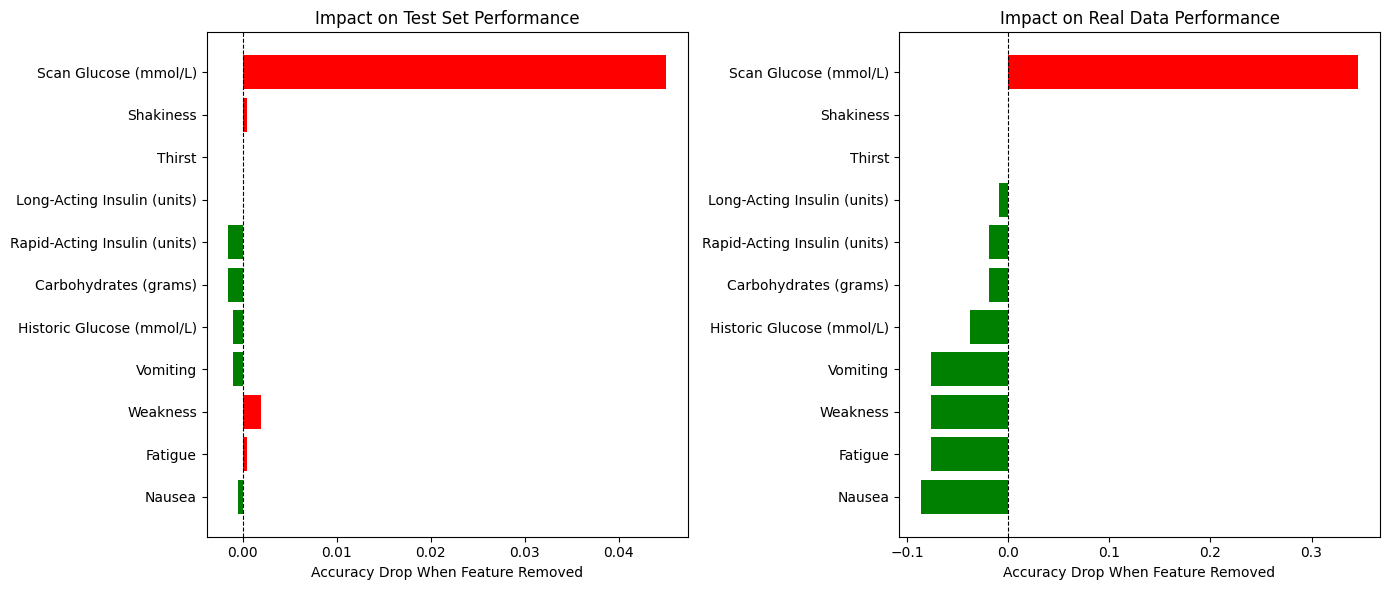

In [73]:

#  ABLATION STUDY - Remove One Feature at a Time


print(" ABLATION STUDY - REMOVING ONE FEATURE AT A TIME")


ablation_results = []

# Loop through each feature
for feature in X_train.columns:
    print(f"\n Testing WITHOUT: {feature}")
    
    # Create dataset without this feature
    X_train_ablated = X_train.drop(columns=[feature])
    X_test_ablated = X_test.drop(columns=[feature])
    X_real_ablated = X_real.drop(columns=[feature])
    
    # Train new model
    model_ablated = RandomForestClassifier(n_estimators=100, random_state=42)
    model_ablated.fit(X_train_ablated, y_train)
    
    # Test performance : synthetic test set
    y_pred_test_ablated = model_ablated.predict(X_test_ablated)
    test_acc = accuracy_score(y_test, y_pred_test_ablated)

    # Real data performance : how well it transfers that learning to actual patient data.
    y_pred_real_ablated = model_ablated.predict(X_real_ablated)
    real_acc = accuracy_score(y_true, y_pred_real_ablated)
    
    # Calculate impact
    test_impact = baseline_test_acc - test_acc
    real_impact = baseline_real_acc - real_acc
    
    ablation_results.append({
        'Removed Feature': feature,
        'Test Accuracy': test_acc,
        'Test Impact': test_impact,
        'Real Accuracy': real_acc,
        'Real Impact': real_impact
    })
    
    print(f"   Test Accuracy: {test_acc:.4f} (Impact: {test_impact:+.4f})")
    print(f"   Real Accuracy: {real_acc:.4f} (Impact: {real_impact:+.4f})")

# Convert to DataFrame
ablation_df = pd.DataFrame(ablation_results)
ablation_df = ablation_df.sort_values('Real Impact', ascending=False)

print("ABLATION STUDY SUMMARY (Sorted by Real Data Impact)")
print(ablation_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Test set impact
axes[0].barh(ablation_df['Removed Feature'], ablation_df['Test Impact'], 
             color=['red' if x > 0 else 'green' for x in ablation_df['Test Impact']])
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Accuracy Drop When Feature Removed')
axes[0].set_title('Impact on Test Set Performance')
axes[0].invert_yaxis()

# Real data impact
axes[1].barh(ablation_df['Removed Feature'], ablation_df['Real Impact'],
             color=['red' if x > 0 else 'green' for x in ablation_df['Real Impact']])
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Accuracy Drop When Feature Removed')
axes[1].set_title('Impact on Real Data Performance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [74]:
# After your ablation loop
print("\n" + "="*60)
print("INTERPRETATION GUIDE:")
print("="*60)
print("✓ Impact > +2%:  Critical feature")
print("✓ Impact +0.5% to +2%:  Helpful feature")
print("✓ Impact -0.5% to +0.5%:  Negligible/redundant feature")
print("✗ Impact < -2%:  Harmful feature (investigate!)")
print("="*60)

# Categorize features
critical = ablation_df[ablation_df['Real Impact'] > 0.02]
helpful = ablation_df[(ablation_df['Real Impact'] > 0.005) & (ablation_df['Real Impact'] <= 0.02)]
negligible = ablation_df[(ablation_df['Real Impact'] >= -0.005) & (ablation_df['Real Impact'] <= 0.005)]

print(f"\nCritical features: {len(critical)}")
print(critical['Removed Feature'].tolist())

print(f"\nHelpful features: {len(helpful)}")
print(helpful['Removed Feature'].tolist())

print(f"\nNegligible/Redundant features: {len(negligible)}")
print(negligible['Removed Feature'].tolist())


INTERPRETATION GUIDE:
✓ Impact > +2%:  Critical feature
✓ Impact +0.5% to +2%:  Helpful feature
✓ Impact -0.5% to +0.5%:  Negligible/redundant feature
✗ Impact < -2%:  Harmful feature (investigate!)

Critical features: 1
['Scan Glucose (mmol/L)']

Helpful features: 0
[]

Negligible/Redundant features: 2
['Shakiness', 'Thirst']


In [75]:

#  FEATURE GROUP ANALYSIS - how well different categories of features perform when used together


print("FEATURE GROUP ANALYSIS")


feature_groups = {
    'Glucose Only': ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)'],
    'Insulin Only': ['Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)'],
    'Carbs Only': ['Carbohydrates (grams)'],
    'Symptoms Only': ['Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness'],
    'Glucose + Insulin': ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 
                          'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)'],
    'No Symptoms': ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)',
                    'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)',
                    'Carbohydrates (grams)']
}

group_results = []

#loop through each feature group
for group_name, features in feature_groups.items():
    print(f"\n Testing with: {group_name}")
    
    # Select only these features
    X_train_group = X_train[features]
    X_test_group = X_test[features]
    X_real_group = X_real[features]
    
    # Train model
    model_group = RandomForestClassifier(n_estimators=100, random_state=42)
    model_group.fit(X_train_group, y_train)
    
    # Evaluate
    test_acc = accuracy_score(y_test, model_group.predict(X_test_group))
    real_acc = accuracy_score(y_true, model_group.predict(X_real_group))
    
    group_results.append({
        'Feature Group': group_name,
        'Num Features': len(features),
        'Test Accuracy': test_acc,
        'Real Accuracy': real_acc
    })
    
    print(f"   Test Accuracy: {test_acc:.4f}")
    print(f"   Real Accuracy: {real_acc:.4f}")

# Display results
group_df = pd.DataFrame(group_results)
group_df = group_df.sort_values('Real Accuracy', ascending=False)

print("\n" + "=" * 60)
print("FEATURE GROUP COMPARISON")
print("=" * 60)
print(group_df.to_string(index=False))

FEATURE GROUP ANALYSIS

 Testing with: Glucose Only
   Test Accuracy: 0.9875
   Real Accuracy: 0.7115

 Testing with: Insulin Only
   Test Accuracy: 0.8010
   Real Accuracy: 0.2404

 Testing with: Carbs Only
   Test Accuracy: 0.7375
   Real Accuracy: 0.2500

 Testing with: Symptoms Only
   Test Accuracy: 0.9285
   Real Accuracy: 0.6250

 Testing with: Glucose + Insulin
   Test Accuracy: 0.9875
   Real Accuracy: 0.7308

 Testing with: No Symptoms
   Test Accuracy: 0.9880
   Real Accuracy: 0.7404

FEATURE GROUP COMPARISON
    Feature Group  Num Features  Test Accuracy  Real Accuracy
      No Symptoms             5         0.9880       0.740385
Glucose + Insulin             4         0.9875       0.730769
     Glucose Only             2         0.9875       0.711538
    Symptoms Only             6         0.9285       0.625000
       Carbs Only             1         0.7375       0.250000
     Insulin Only             2         0.8010       0.240385


 FEATURE CORRELATION ANALYSIS


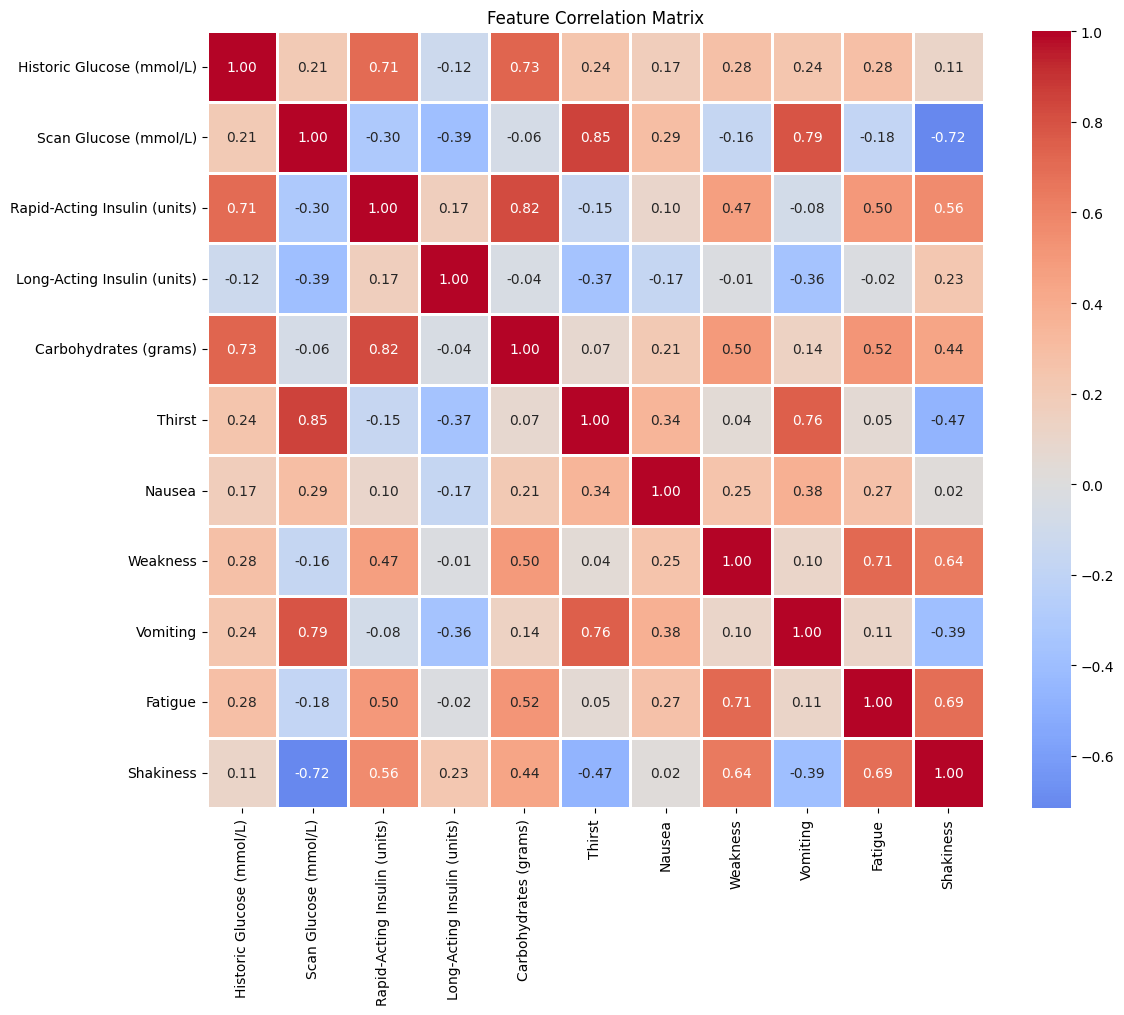

In [76]:

#  FEATURE CORRELATION ANALYSIS

print(" FEATURE CORRELATION ANALYSIS")


# Calculate correlation matrix
correlation_matrix = X_train.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [77]:
%pip install xgboost

## 3.1 XGBoost
print("="*60)
print("TRAINING: XGBoost")
print("="*60)

from xgboost import XGBClassifier

# Calculate class weights for XGBoost
class_counts = np.bincount(y_train)
class_weights = len(y_train) / (len(class_counts) * class_counts)
sample_weights = np.array([class_weights[int(y)] for y in y_train])

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# Evaluate
y_pred_test_xgb = xgb_model.predict(X_test)
y_pred_real_xgb = xgb_model.predict(X_real)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test_xgb):.4f}")
print(f"Real Accuracy: {accuracy_score(y_true, y_pred_real_xgb):.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test_xgb, 
                            target_names=['Hypo', 'Normal', 'Hyper', 'DKA']))

Note: you may need to restart the kernel to use updated packages.
TRAINING: XGBoost
Test Accuracy: 0.9915
Real Accuracy: 0.9904

Classification Report (Test Set):
              precision    recall  f1-score   support

        Hypo       0.99      0.99      0.99      1334
      Normal       0.98      0.97      0.98       346
       Hyper       0.99      1.00      1.00       140
         DKA       1.00      1.00      1.00       180

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



🎯 XGBoost Model Accuracy on Balanced Real Data: 0.9903846153846154

📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98        26
           1       0.96      1.00      0.98        26
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        26

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104



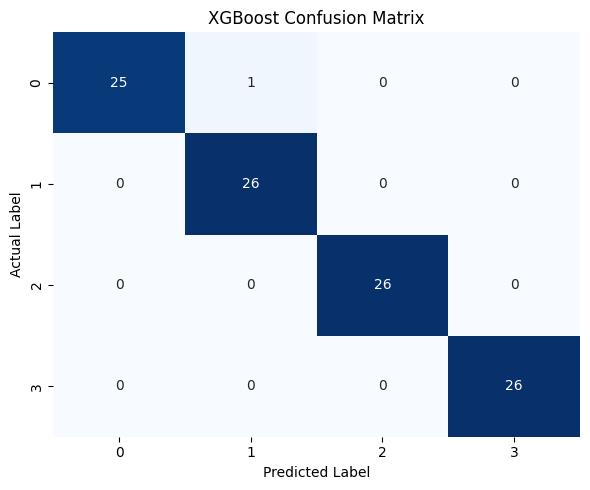

In [78]:
# ✅ Make predictions on the real dataset
y_pred_real = xgb_model.predict(X_real)

# ✅ Calculate accuracy
accuracy = accuracy_score(y_true, y_pred_real)
print("🎯 XGBoost Model Accuracy on Balanced Real Data:", accuracy)

# ✅ Classification Report
print("\n📊 Classification Report:\n", classification_report(y_true, y_pred_real))

# ✅ Confusion Matrix
cm = confusion_matrix(y_true, y_pred_real)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

In [79]:
## 3.2 Support Vector Machine (SVM)
print("="*60)
print("TRAINING: SVM")
print("="*60)

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# SVM requires feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_real_scaled = scaler.transform(X_real)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_test_svm = svm_model.predict(X_test_scaled)
y_pred_real_svm = svm_model.predict(X_real_scaled)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test_svm):.4f}")
print(f"Real Accuracy: {accuracy_score(y_true, y_pred_real_svm):.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test_svm,
                            target_names=['Hypo', 'Normal', 'Hyper', 'DKA']))

TRAINING: SVM
Test Accuracy: 0.9640
Real Accuracy: 0.8077

Classification Report (Test Set):
              precision    recall  f1-score   support

        Hypo       0.99      0.97      0.98      1334
      Normal       0.89      0.90      0.90       346
       Hyper       0.85      0.99      0.91       140
         DKA       1.00      0.99      1.00       180

    accuracy                           0.96      2000
   macro avg       0.93      0.97      0.95      2000
weighted avg       0.97      0.96      0.96      2000



In [80]:
print("="*60)
print("TRAINING: Logistic Regression")
print("="*60)

from sklearn.linear_model import LogisticRegression

# Use scaled features
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    multi_class='multinomial'
)

lr_model.fit(X_train_scaled, y_train)

y_pred_test_lr = lr_model.predict(X_test_scaled)
y_pred_real_lr = lr_model.predict(X_real_scaled)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test_lr):.4f}")
print(f"Real Accuracy: {accuracy_score(y_true, y_pred_real_lr):.4f}")

TRAINING: Logistic Regression


/home/blessing/DIABETES_PROJECT/diabetes_project/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test Accuracy: 0.9745
Real Accuracy: 0.8269


MODEL COMPARISON SUMMARY
              Model  Test Accuracy  Real Accuracy  Generalization Gap
      Random Forest         0.9920       0.894231            0.097769
            XGBoost         0.9915       0.990385            0.001115
                SVM         0.9640       0.807692            0.156308
Logistic Regression         0.9745       0.826923            0.147577


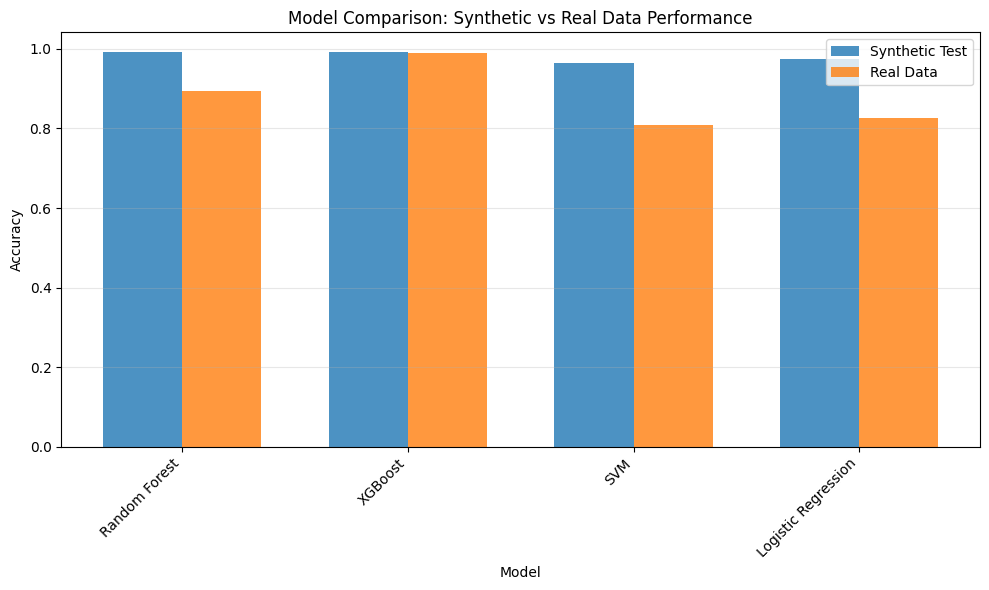


 Best Model: XGBoost
   Real Data Accuracy: 0.9904


In [81]:
# SECTION 4: MODEL COMPARISON
# ============================================================================
print("="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

comparison_results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'SVM', 'Logistic Regression'],
    'Test Accuracy': [
        baseline_test_acc,
        accuracy_score(y_test, y_pred_test_xgb),
        accuracy_score(y_test, y_pred_test_svm),
        accuracy_score(y_test, y_pred_test_lr)
    ],
    'Real Accuracy': [
        baseline_real_acc,
        accuracy_score(y_true, y_pred_real_xgb),
        accuracy_score(y_true, y_pred_real_svm),
        accuracy_score(y_true, y_pred_real_lr)
    ]
})

# Calculate generalization gap
comparison_results['Generalization Gap'] = (
    comparison_results['Test Accuracy'] - comparison_results['Real Accuracy']
)

print(comparison_results.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_results))
width = 0.35

ax.bar(x - width/2, comparison_results['Test Accuracy'], width, 
       label='Synthetic Test', alpha=0.8)
ax.bar(x + width/2, comparison_results['Real Accuracy'], width,
       label='Real Data', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: Synthetic vs Real Data Performance')
ax.set_xticks(x)
ax.set_xticklabels(comparison_results['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Best model
best_model_idx = comparison_results['Real Accuracy'].idxmax()
best_model = comparison_results.loc[best_model_idx, 'Model']
best_accuracy = comparison_results.loc[best_model_idx, 'Real Accuracy']

print(f"\n Best Model: {best_model}")
print(f"   Real Data Accuracy: {best_accuracy:.4f}")

ABLATION STUDY - XGBoost

Baseline XGBoost Performance:
  Test Accuracy: 0.9915
  Real Accuracy: 0.9904

REMOVING FEATURES ONE AT A TIME

 Testing WITHOUT: Historic Glucose (mmol/L)
   Test Accuracy: 0.9915 (Impact: +0.0000)
   Real Accuracy: 0.9808 (Impact: +0.0096)

 Testing WITHOUT: Scan Glucose (mmol/L)
   Test Accuracy: 0.9390 (Impact: +0.0525)
   Real Accuracy: 0.3077 (Impact: +0.6827)

 Testing WITHOUT: Rapid-Acting Insulin (units)
   Test Accuracy: 0.9910 (Impact: +0.0005)
   Real Accuracy: 0.9904 (Impact: +0.0000)

 Testing WITHOUT: Long-Acting Insulin (units)
   Test Accuracy: 0.9910 (Impact: +0.0005)
   Real Accuracy: 0.9808 (Impact: +0.0096)

 Testing WITHOUT: Carbohydrates (grams)
   Test Accuracy: 0.9920 (Impact: -0.0005)
   Real Accuracy: 0.9904 (Impact: +0.0000)

 Testing WITHOUT: Thirst
   Test Accuracy: 0.9915 (Impact: +0.0000)
   Real Accuracy: 0.9904 (Impact: +0.0000)

 Testing WITHOUT: Nausea
   Test Accuracy: 0.9915 (Impact: +0.0000)
   Real Accuracy: 0.9904 (Impa

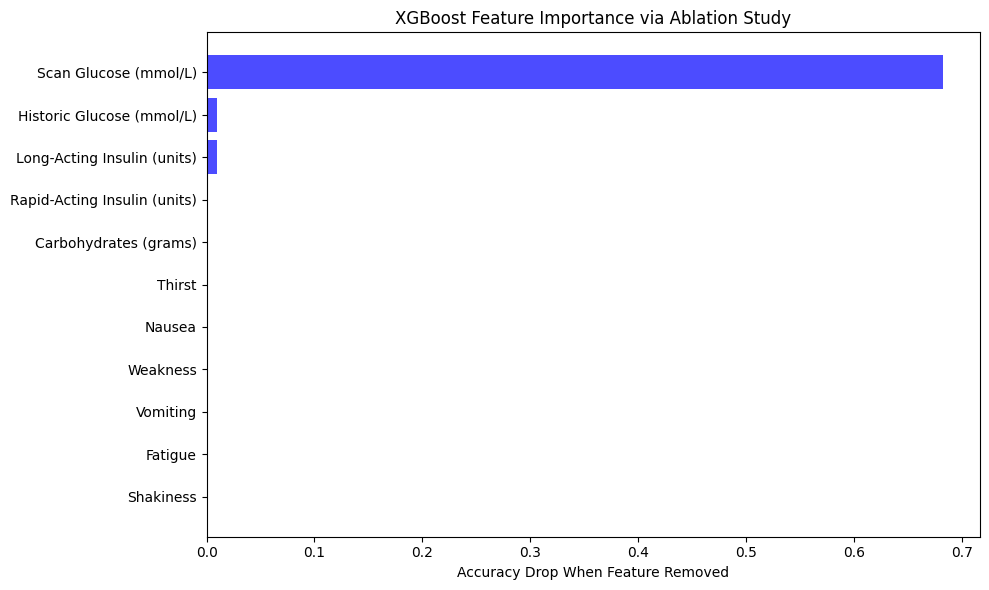

In [82]:
# ============================================================================
# ABLATION STUDY: XGBoost (Best Performing Model)
# ============================================================================
print("="*60)
print("ABLATION STUDY - XGBoost")
print("="*60)

# Baseline XGBoost performance
print("\nBaseline XGBoost Performance:")
print(f"  Test Accuracy: {accuracy_score(y_test, y_pred_test_xgb):.4f}")
print(f"  Real Accuracy: {accuracy_score(y_true, y_pred_real_xgb):.4f}")

baseline_test_xgb = accuracy_score(y_test, y_pred_test_xgb)
baseline_real_xgb = accuracy_score(y_true, y_pred_real_xgb)

print("\n" + "="*60)
print("REMOVING FEATURES ONE AT A TIME")
print("="*60)

ablation_xgb_results = []

for feature in X_train.columns:
    print(f"\n Testing WITHOUT: {feature}")
    
    # Create dataset without this feature
    X_train_ablated = X_train.drop(columns=[feature])
    X_test_ablated = X_test.drop(columns=[feature])
    X_real_ablated = X_real.drop(columns=[feature])
    
    # Train XGBoost without this feature
    xgb_ablated = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss'
    )
    
    # Calculate sample weights
    class_counts = np.bincount(y_train)
    class_weights = len(y_train) / (len(class_counts) * class_counts)
    sample_weights = np.array([class_weights[int(y)] for y in y_train])
    
    xgb_ablated.fit(X_train_ablated, y_train, sample_weight=sample_weights)
    
    # Evaluate
    y_pred_test_abl = xgb_ablated.predict(X_test_ablated)
    y_pred_real_abl = xgb_ablated.predict(X_real_ablated)
    
    test_acc = accuracy_score(y_test, y_pred_test_abl)
    real_acc = accuracy_score(y_true, y_pred_real_abl)
    
    # Calculate impact
    test_impact = baseline_test_xgb - test_acc
    real_impact = baseline_real_xgb - real_acc
    
    ablation_xgb_results.append({
        'Removed Feature': feature,
        'Test Accuracy': test_acc,
        'Test Impact': test_impact,
        'Real Accuracy': real_acc,
        'Real Impact': real_impact
    })
    
    print(f"   Test Accuracy: {test_acc:.4f} (Impact: {test_impact:+.4f})")
    print(f"   Real Accuracy: {real_acc:.4f} (Impact: {real_impact:+.4f})")

# Convert to DataFrame
ablation_xgb_df = pd.DataFrame(ablation_xgb_results)
ablation_xgb_df = ablation_xgb_df.sort_values('Real Impact', ascending=False)

print("\n" + "="*60)
print("XGBoost ABLATION STUDY SUMMARY")
print("="*60)
print(ablation_xgb_df.to_string(index=False))

# Visualize feature importance impact
plt.figure(figsize=(10, 6))
plt.barh(ablation_xgb_df['Removed Feature'], ablation_xgb_df['Real Impact'], color='blue', alpha=0.7)
plt.xlabel('Accuracy Drop When Feature Removed')
plt.title('XGBoost Feature Importance via Ablation Study')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


TRAINING: Neural Network
Note: you may need to restart the kernel to use updated packages.

Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,444 (13.45 KB)

 Trainable params: 3,444 (13.45 KB)

 Non-trainable params: 0 (0.00 B)


Test Accuracy: 0.9760
Real Accuracy: 0.8462

Classification Report (Real Data):
              precision    recall  f1-score   support

        Hypo       1.00      0.81      0.89        26
      Normal       0.83      0.96      0.89        26
       Hyper       0.71      0.96      0.82        26
         DKA       0.94      0.65      0.77        26

    accuracy                           0.85       104
   macro avg       0.87      0.85      0.84       104
weighted avg       0.87      0.85      0.84       104



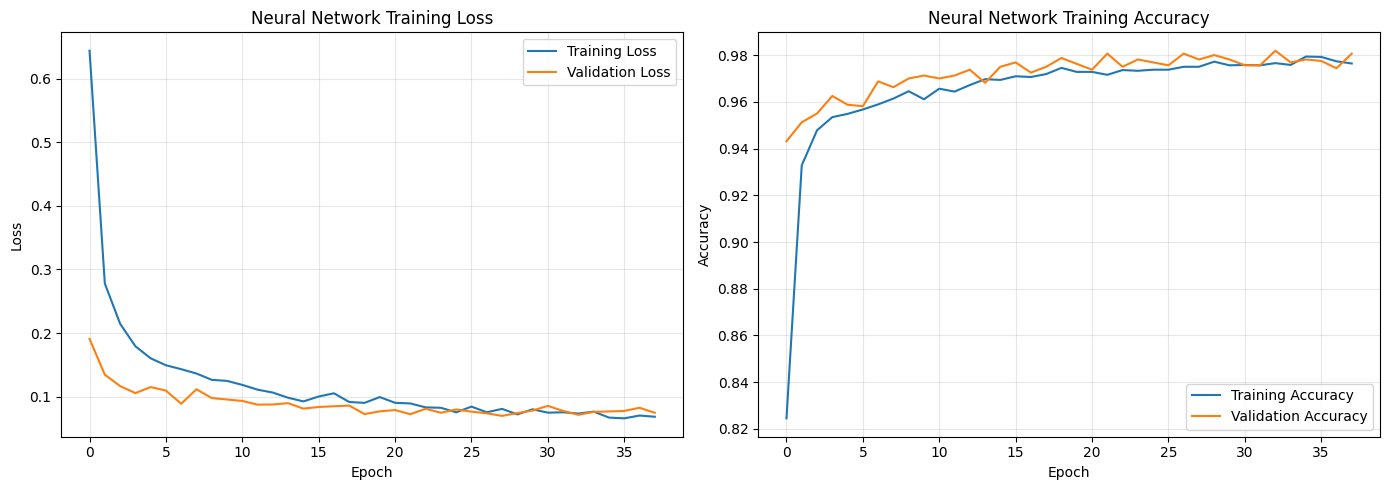

In [83]:
# ============================================================================
# SECTION 3.5: NEURAL NETWORK (Deep Learning Comparison)
# ============================================================================
print("="*60)
print("TRAINING: Neural Network")
print("="*60)

# Install TensorFlow in the notebook environment if it's missing
# (use the magics-style pip install as required for Notebook fixes)
%pip install tensorflow --quiet

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

# Scale features (critical for neural networks)
scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train)
X_test_nn = scaler_nn.transform(X_test)
X_real_nn = scaler_nn.transform(X_real)

# Calculate class weights
class_weights_dict = {}
class_counts = np.bincount(y_train)
for i in range(len(class_counts)):
    class_weights_dict[i] = len(y_train) / (len(class_counts) * class_counts[i])

# Build Neural Network
nn_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(4, activation='softmax')  # 4 classes
])

nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Architecture:")
nn_model.summary()

# Train with early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_nn, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=0
)

# Evaluate
y_pred_test_nn_probs = nn_model.predict(X_test_nn, verbose=0)
y_pred_test_nn = np.argmax(y_pred_test_nn_probs, axis=1)

y_pred_real_nn_probs = nn_model.predict(X_real_nn, verbose=0)
y_pred_real_nn = np.argmax(y_pred_real_nn_probs, axis=1)

test_acc_nn = accuracy_score(y_test, y_pred_test_nn)
real_acc_nn = accuracy_score(y_true, y_pred_real_nn)

print(f"\nTest Accuracy: {test_acc_nn:.4f}")
print(f"Real Accuracy: {real_acc_nn:.4f}")

print("\nClassification Report (Real Data):")
print(classification_report(y_true, y_pred_real_nn,
                            target_names=['Hypo', 'Normal', 'Hyper', 'DKA']))

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Neural Network Training Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Neural Network Training Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [84]:
# ============================================================================
# SECTION 4: COMPREHENSIVE MODEL COMPARISON
# ============================================================================

comparison_results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'SVM', 
              'Logistic Regression', 'Neural Network'],
    'Test Accuracy': [
        baseline_test_acc,
        accuracy_score(y_test, y_pred_test_xgb),
        accuracy_score(y_test, y_pred_test_svm),
        accuracy_score(y_test, y_pred_test_lr),
        test_acc_nn
    ],
    'Real Accuracy': [
        baseline_real_acc,
        accuracy_score(y_true, y_pred_real_xgb),
        accuracy_score(y_true, y_pred_real_svm),
        accuracy_score(y_true, y_pred_real_lr),
        real_acc_nn
    ]
})

comparison_results['Generalization Gap'] = (
    comparison_results['Test Accuracy'] - comparison_results['Real Accuracy']
)

comparison_results = comparison_results.sort_values('Real Accuracy', ascending=False)

print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(comparison_results.to_string(index=False))

# Highlight best model
best_idx = comparison_results['Real Accuracy'].idxmax()
best_model = comparison_results.loc[best_idx, 'Model']
best_real_acc = comparison_results.loc[best_idx, 'Real Accuracy']
best_gap = comparison_results.loc[best_idx, 'Generalization Gap']

print(f"\n BEST MODEL: {best_model}")
print(f"   Real Data Accuracy: {best_real_acc:.4f}")
print(f"   Generalization Gap: {best_gap:.4f}")
print(f"   Interpretation: {'Excellent generalization' if best_gap < 0.05 else 'Moderate overfitting'}")

FINAL MODEL COMPARISON
              Model  Test Accuracy  Real Accuracy  Generalization Gap
            XGBoost         0.9915       0.990385            0.001115
      Random Forest         0.9920       0.894231            0.097769
     Neural Network         0.9760       0.846154            0.129846
Logistic Regression         0.9745       0.826923            0.147577
                SVM         0.9640       0.807692            0.156308

 BEST MODEL: XGBoost
   Real Data Accuracy: 0.9904
   Generalization Gap: 0.0011
   Interpretation: Excellent generalization


In [ ]:
# ============================================================================
# SAVE BEST MODEL (XGBoost)
# ============================================================================
print("="*60)
print("SAVING BEST MODEL: XGBoost")
print("="*60)

import joblib
import pickle

# Save XGBoost model
joblib.dump(xgb_model, 'diabetes_xgboost_model.joblib')

# Save scaler (if used)
# Note: XGBoost doesn't require scaling, but save for consistency
joblib.dump(scaler_nn, 'feature_scaler.joblib')  # Only if you use scaling

# Save comprehensive metadata
model_metadata = {
    'model_type': 'XGBoost',
    'version': '3.0',
    'training_date': '2025-01-XX',
    
    # Feature information
    'feature_names': X_train.columns.tolist(),
    'n_features': len(X_train.columns),
    
    # Class information
    'condition_map': {
        0: "Hypoglycemia", 
        1: "Normal", 
        2: "Hyperglycemia", 
        3: "DKA"
    },
    'class_thresholds': {
        'Hypoglycemia': '< 3.9 mmol/L',
        'Normal': '3.9 - 7.0 mmol/L',
        'Hyperglycemia': '7.0 - 14.0 mmol/L',
        'DKA': '≥ 14.0 mmol/L'
    },
    
    # Performance metrics
    'test_accuracy': accuracy_score(y_test, y_pred_test_xgb),
    'real_accuracy': accuracy_score(y_true, y_pred_real_xgb),
    'generalization_gap': accuracy_score(y_test, y_pred_test_xgb) - accuracy_score(y_true, y_pred_real_xgb),
    
    # Feature importance
    'feature_importance': dict(zip(X_train.columns, xgb_model.feature_importances_)),
    
    # Training info
    'n_training_samples': len(X_train),
    'n_test_samples': len(X_test),
    'n_real_samples': len(X_real),
    'class_distribution': dict(zip(*np.unique(y_train, return_counts=True))),
    
    # Model hyperparameters
    'hyperparameters': {
        'n_estimators': 100,
        'max_depth': 6,
        'learning_rate': 0.1
    }
}

with open('xgboost_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print(" XGBoost model saved as 'diabetes_xgboost_model.joblib'")
print(" Metadata saved as 'xgboost_metadata.pkl'")
print(" Scaler saved as 'feature_scaler.joblib'")

# Verify saving worked
print("\n Verifying saved files...")
loaded_model = joblib.load('diabetes_xgboost_model.joblib')
loaded_metadata = pickle.load(open('xgboost_metadata.pkl', 'rb'))

test_pred = loaded_model.predict(X_test)
test_acc_loaded = accuracy_score(y_test, test_pred)

print(f"   Loaded model accuracy: {test_acc_loaded:.4f}")
print(f"   Original model accuracy: {accuracy_score(y_test, y_pred_test_xgb):.4f}")
print(f"   Match: {'✓' if abs(test_acc_loaded - accuracy_score(y_test, y_pred_test_xgb)) < 0.0001 else '✗'}")

SAVING BEST MODEL: XGBoost
✅ XGBoost model saved as 'diabetes_xgboost_model.joblib'
✅ Metadata saved as 'xgboost_metadata.pkl'
✅ Scaler saved as 'feature_scaler.joblib'

 Verifying saved files...
   Loaded model accuracy: 0.9915
   Original model accuracy: 0.9915
   Match: ✓
